In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append("..")
from src.data_loader import load_data
from src.metrics import (total_return,sharpe_ratio,max_drawdown)

In [6]:
def run_sma_backtest(ticker, fast=50, slow=200):
    df = load_data(ticker)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df["SMA_50"] = df["Close"].rolling(fast).mean()
    df["SMA_200"] = df["Close"].rolling(slow).mean()

    df["Signal"] = 0
    df.loc[df["SMA_50"] > df["SMA_200"], "Signal"] = 1

    df["Returns"] = df["Close"].pct_change()

    df["Strategy_Returns"] = (
        df["Signal"].shift(1) * df["Returns"]
    )

    df["Equity"] = (
        1 + df["Strategy_Returns"].fillna(0)
    ).cumprod()

    return df

In [7]:
spy = run_sma_backtest("SPY")
aapl = run_sma_backtest("AAPL")
xom=run_sma_backtest("XOM")
ge=run_sma_backtest("GE")

d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")
[*********************100%***********************]  1 of 1 completed
d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")


[*********************100%***********************]  1 of 1 completed
d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")


[*********************100%***********************]  1 of 1 completed
d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")


[*********************100%***********************]  1 of 1 completed


In [9]:
comparison = {
    "SPY": {
        "Return": round(total_return(spy["Equity"])*100, 2),
        "Sharpe": round(sharpe_ratio(spy["Strategy_Returns"].dropna()), 2),
        "MaxDD": round(max_drawdown(spy["Equity"])*100, 2)
    },

    "AAPL": {
        "Return": round(total_return(aapl["Equity"])*100, 2),
        "Sharpe": round(sharpe_ratio(aapl["Strategy_Returns"].dropna()), 2),
        "MaxDD": round(max_drawdown(aapl["Equity"])*100, 2)
    },

    "XOM": {
        "Return": round(total_return(xom["Equity"])*100, 2),
        "Sharpe": round(sharpe_ratio(xom["Strategy_Returns"].dropna()), 2),
        "MaxDD": round(max_drawdown(xom["Equity"])*100, 2)
    },

    "GE": {
        "Return": round(total_return(ge["Equity"])*100, 2),
        "Sharpe": round(sharpe_ratio(ge["Strategy_Returns"].dropna()), 2),
        "MaxDD": round(max_drawdown(ge["Equity"])*100, 2)
    }
}
comparison

{'SPY': {'Return': 107.86, 'Sharpe': 0.96, 'MaxDD': -18.76},
 'AAPL': {'Return': 30.64, 'Sharpe': 0.3, 'MaxDD': -30.31},
 'XOM': {'Return': 181.01, 'Sharpe': 0.82, 'MaxDD': -30.23},
 'GE': {'Return': 621.75, 'Sharpe': 1.34, 'MaxDD': -21.36}}

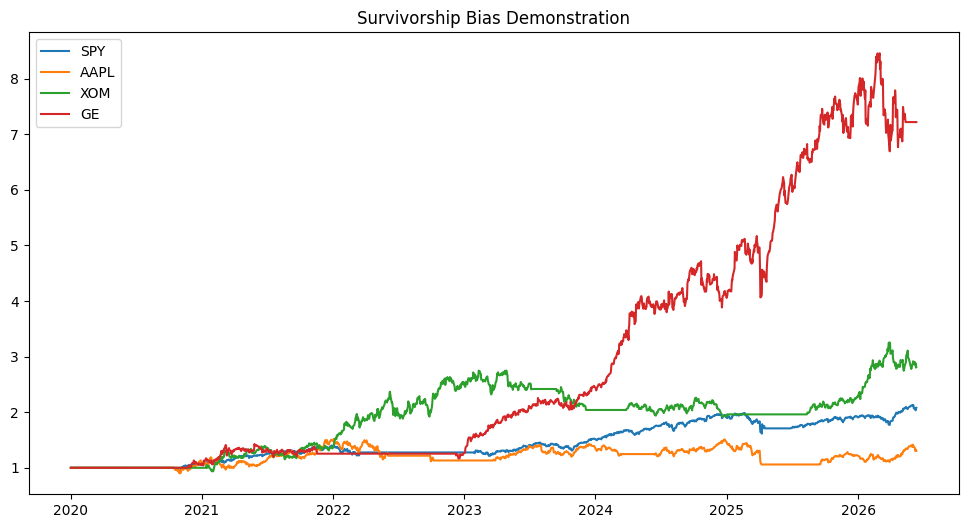

In [10]:
plt.figure(figsize=(12,6))

plt.plot(spy.index,spy["Equity"],label="SPY")
plt.plot(aapl.index,aapl["Equity"],label="AAPL")
plt.plot(xom.index,xom["Equity"],label="XOM")
plt.plot(ge.index,ge["Equity"],label="GE")
plt.title("Survivorship Bias Demonstration")

plt.legend()

plt.show()

## Results

| Asset | Total Return | Sharpe Ratio | Maximum Drawdown |
|---------|--------------|---------------|-------------------|
| SPY | 107.86% | 0.96 | -18.76% |
| AAPL | 30.64% | 0.30 | -30.31% |
| XOM | 181.01% | 0.82 | -30.23% |
| GE | 621.75% | 1.34 | -21.36% |